## Prima prova di statistica

### Generazione di numeri causali

In [178]:
import numpy as np
import math
import matplotlib.pyplot as plt

N=1000
nbins=10

data = np.random.uniform(0,1,N) #genera N numeri casuali tra 0 e 1

### Creazione istogramma

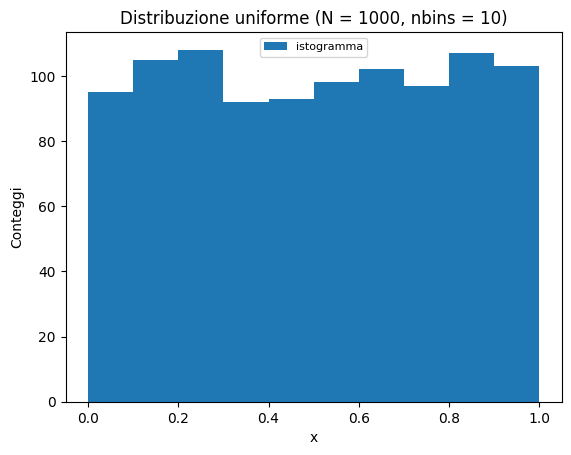

In [179]:
x, bordi, patches= plt.hist(data, bins=nbins, range=(0,1), label='istogramma')#x è un array con i conteggi in ogni bin, bordi è un array con i bordi dei bin,
                                                                         #patches è una lista di oggetti che rappresentano i rettangoli dell'istogramma
                                                                             #plt.hist() restituisce questi tre oggetti
plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione uniforme (N = {N}, nbins = {nbins})")
plt.legend(loc='best', prop={'size': 8})
plt.show()

### Probabilità per bin

In [180]:
pi=1/nbins #la probabilità di ogni bin è 1/nbins, perché la distribuzione è uniforme e ci sono nbins bin
print(f"la probabilità di ogni bin è {pi}")

la probabilità di ogni bin è 0.1


### Calcoliamo mu e sigma

In [181]:
mu= N * pi #la media della distribuzione binomiale è N*p
sigma= math.sqrt(N * pi * (1 - pi)) #la deviazione standard della distribuzione binomiale è sqrt(N*p*(1-p))
print(f"la media della distribuzione binomiale è {mu}")
print(f"la deviazione standard della distribuzione binomiale è {sigma}")
print(f"quasi tutti i miei valori si trovano a meno di una deviazione standard dalla media: {mu} ± {3*sigma}")

la media della distribuzione binomiale è 100.0
la deviazione standard della distribuzione binomiale è 9.486832980505138
quasi tutti i miei valori si trovano a meno di una deviazione standard dalla media: 100.0 ± 28.460498941515414


### Curva di distribuzione teorica

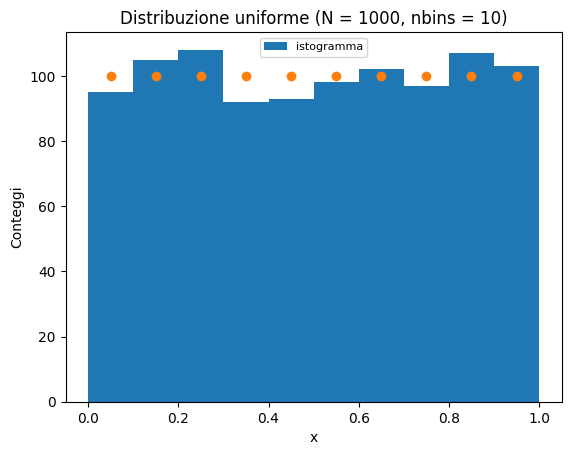

In [182]:
larghezza_bin = 1/nbins #la larghezza di ogni bin è 1/nbins, perché la distribuzione è uniforme e ci sono nbins bin
centri_bin = bordi[:-1] + larghezza_bin/2 #i centri dei bin si trovano a metà tra i bordi, quindi prendo i bordi tranne l'ultimo e aggiungo metà della larghezza del bin
lista = [mu] * nbins
x, bordi, patches= plt.hist(data, bins=nbins, range=(0,1), label='istogramma')#
plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione uniforme (N = {N}, nbins = {nbins})")
plt.legend(loc='best', prop={'size': 8})
plt.plot(centri_bin, lista, label='Dati', marker='o', linestyle='None') #(ascisse, ordinate, etichetta, marker, stile della linea)
plt.show()


### Ripetiamo 1000 volte e non grafichiamo gli istogrammi

(array([ 1.,  0.,  2.,  3.,  6., 11., 14., 25., 31., 46., 54., 88., 62.,
        81., 85., 84., 73., 67., 57., 55., 46., 36., 22., 18., 15.,  8.,
         4.,  0.,  3.,  2.]),
 array([ 70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,  90.,
         92.,  94.,  96.,  98., 100., 102., 104., 106., 108., 110., 112.,
        114., 116., 118., 120., 122., 124., 126., 128., 130.]),
 <BarContainer object of 30 artists>)

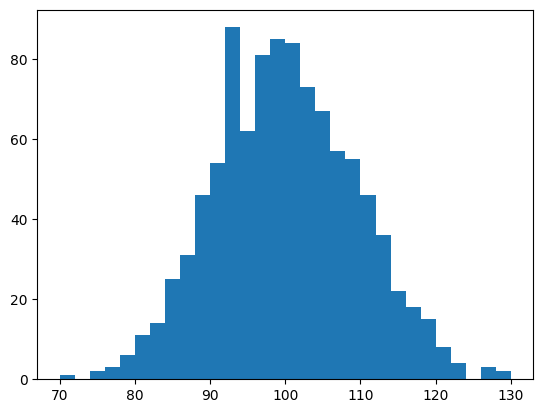

In [183]:
M=1000
conteggi_bin =[]
i=5

for j in range(M):
    # genero i dati
    data = np.random.uniform(0, 1, N)

    # calcolo istogramma senza graficare
    x, bordi = np.histogram(data, bins=10, range=(0,1))

    # salvo solo il conteggio del bin scelto
    conteggi_bin.append(x[i])

plt.hist(conteggi_bin, bins=30, range=(70,130), label=f'Conteggi bin {i}')
    

### Creazione distribuzione binomiale

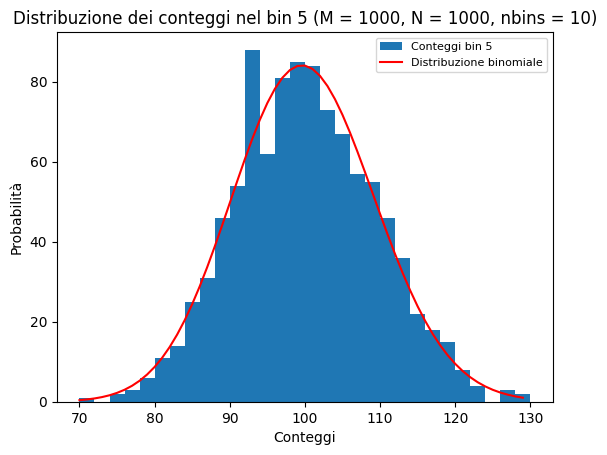

In [ ]:
def binomiale(n, k, p):
    coeff = math.comb(n, k) #calcolo il coefficiente binomiale, che è il numero di modi in cui posso scegliere k successi in n prove
    return coeff * (p**k) * ((1-p)**(n-k)) #formula della distribuzione binomiale

k_values = np.arange(70, 130) #valori di k da 70 a 130
binomiale_values = [binomiale(N, k, pi) for k in k_values] #calcolo la distribuzione binomiale per ogni valore di k
dx=2 #calcolo la larghezza dei bin dell'istogramma
pn=np.array(binomiale_values)*N*dx #normalizzo la distribuzione binomiale moltiplicando per N e dividendo per dx, in modo da confrontarla con l'istogramma
plt.hist(conteggi_bin, bins=30, range=(70,130), label=f'Conteggi bin {i}')
plt.plot(k_values, pn, label='Distribuzione binomiale', color='red') #plotto la distribuzione binomiale
plt.xlabel("Conteggi")
plt.ylabel("Probabilità")
plt.title(f"Distribuzione dei conteggi nel bin {i} (M = {M}, N = {N}, nbins = {nbins})")
plt.legend(loc='best', prop={'size': 8})
plt.show()      

### Creazione distribuzione Poissoniana

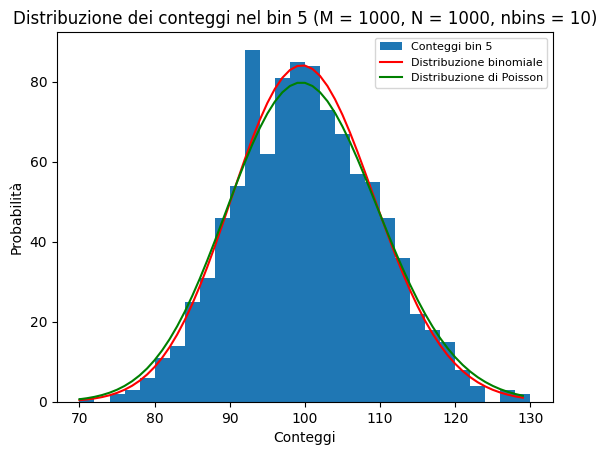

In [186]:
def poisson(lam, k):
    return (lam**k) * math.exp(-lam) / math.factorial(k) #formula della distribuzione di Poisson
poisson_values = [poisson(mu, k) for k in k_values] #calcolo la distribuzione di Poisson per ogni valore di k
pn_poisson = np.array(poisson_values)*N*dx #normalizzo la distribuzione
plt.hist(conteggi_bin, bins=30, range=(70,130), label=f'Conteggi bin {i}')
plt.plot(k_values, pn, label='Distribuzione binomiale', color='red')
plt.plot(k_values, pn_poisson, label='Distribuzione di Poisson', color='green')
plt.xlabel("Conteggi")
plt.ylabel("Probabilità")
plt.title(f"Distribuzione dei conteggi nel bin {i} (M = {M}, N = {N}, nbins = {nbins})")
plt.legend(loc='best', prop={'size': 8})
plt.show()